<a href="https://colab.research.google.com/github/RughmaMalik/developershub_tasks/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [2]:
from google.colab import files
uploaded = files.upload()

Saving loan_dataset.csv to loan_dataset (1).csv


In [3]:
df = pd.read_csv('loan_dataset.csv')

In [4]:
df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [5]:
# Fill numeric missing values with median
num_cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


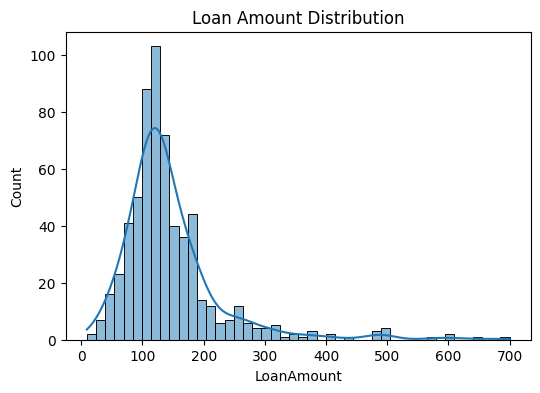

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

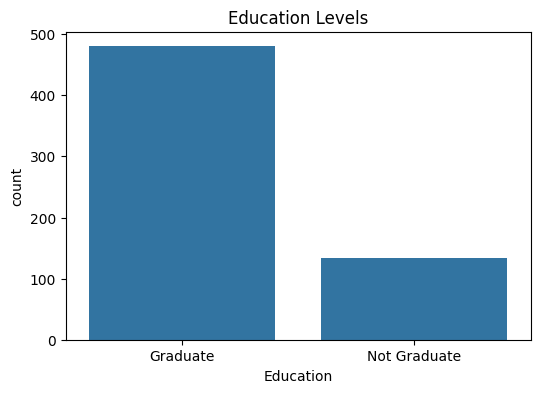

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=df)
plt.title("Education Levels")
plt.show()

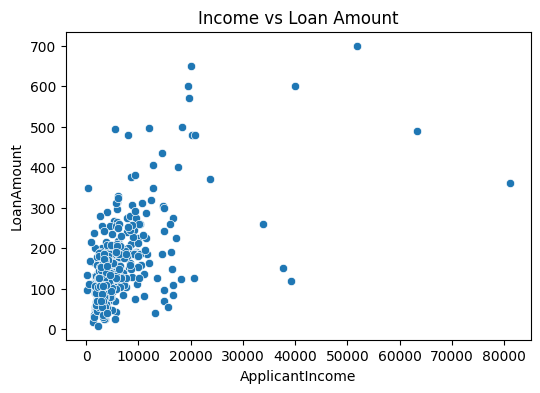

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['ApplicantIncome'], y=df['LoanAmount'])
plt.title("Income vs Loan Amount")
plt.show()

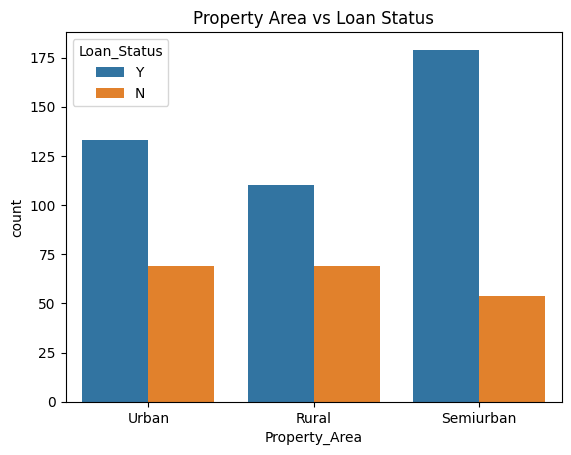

In [9]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Status")
plt.show()


In [10]:
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])


In [11]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
tree_model = DecisionTreeClassifier(max_depth=4)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [14]:
log_model = LogisticRegression(max_iter=5000, solver='liblinear')

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [15]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("\n",classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7886178861788617

Confusion Matrix:
 [[18 25]
 [ 1 79]]

               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [16]:
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, tree_pred))
print("\n",classification_report(y_test, tree_pred))

Decision Tree Accuracy: 0.7723577235772358

Confusion Matrix:
 [[18 25]
 [ 3 77]]

               precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123

